# YOLO v8 Training

### First cell: Imports

Path library: makes sure paths are consistent on all machines.
yaml: data formatting for model training
cv2: helps loading images
matplotlib: Plotting data for implementations.
ultralytics: for yolo model 

In [1]:
import os
import random
from pathlib import Path
import yaml
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

### Path set up

This cell defines the main paths used throughout the notebook.

The goal is to keep the notebook portable across machines by using the current working directory as the project root instead of hardcoding absolute Windows paths. From that root, we point to:

- the dataset folder
- the data.yaml file
- the training and validation image folders
- the training and validation label folders

In [2]:
PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset_yolo"
DATA_YAML = DATASET_DIR / "data.yaml"

IMAGES_TRAIN = DATASET_DIR / "images" / "train"
IMAGES_VAL = DATASET_DIR / "images" / "val"
LABELS_TRAIN = DATASET_DIR / "labels" / "train"
LABELS_VAL = DATASET_DIR / "labels" / "val"

print("Project root:", PROJECT_ROOT)
print("Dataset dir :", DATASET_DIR)
print("data.yaml   :", DATA_YAML)

Project root: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project
Dataset dir : C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo
data.yaml   : C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\data.yaml


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATASET_DIR = PROJECT_ROOT / "dataset_yolo"
DATA_YAML = DATASET_DIR / "data.yaml"

IMAGES_TRAIN = DATASET_DIR / "images" / "train"
IMAGES_VAL = DATASET_DIR / "images" / "val"
LABELS_TRAIN = DATASET_DIR / "labels" / "train"
LABELS_VAL = DATASET_DIR / "labels" / "val"

required_paths = {
    "DATASET_DIR": DATASET_DIR,
    "DATA_YAML": DATA_YAML,
    "IMAGES_TRAIN": IMAGES_TRAIN,
    "IMAGES_VAL": IMAGES_VAL,
    "LABELS_TRAIN": LABELS_TRAIN,
    "LABELS_VAL": LABELS_VAL,
}

print("Current working directory:", PROJECT_ROOT)
print()

missing = []
for name, path in required_paths.items():
    exists = path.exists()
    print(f"{name}: {path} -> {'OK' if exists else 'MISSING'}")
    if not exists:
        missing.append((name, path))

if missing:
    raise FileNotFoundError("Some required training paths are missing. See list above.")

Current working directory: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project

DATASET_DIR: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo -> OK
DATA_YAML: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\data.yaml -> OK
IMAGES_TRAIN: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\train -> OK
IMAGES_VAL: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\val -> OK
LABELS_TRAIN: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\labels\train -> OK
LABELS_VAL: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\labels\val -> OK


### Yaml file check

In [4]:
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_config = yaml.safe_load(f)

print("data.yaml contents:")
print(data_config)

data.yaml contents:
{'path': 'dataset_yolo', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'names': {0: 'licence'}}


### Dataset details

In [5]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

train_images = [p for p in IMAGES_TRAIN.iterdir() if p.suffix.lower() in IMAGE_EXTS]
val_images = [p for p in IMAGES_VAL.iterdir() if p.suffix.lower() in IMAGE_EXTS]
train_labels = list(LABELS_TRAIN.glob("*.txt"))
val_labels = list(LABELS_VAL.glob("*.txt"))

print(f"Train images: {len(train_images)}")
print(f"Val images  : {len(val_images)}")
print(f"Train labels: {len(train_labels)}")
print(f"Val labels  : {len(val_labels)}")

Train images: 303
Val images  : 65
Train labels: 303
Val labels  : 65


In [6]:
def find_missing_labels(image_files, label_dir):
    missing = []
    for img_path in image_files:
        label_path = label_dir / f"{img_path.stem}.txt"
        if not label_path.exists():
            missing.append(img_path.name)
    return missing

missing_train = find_missing_labels(train_images, LABELS_TRAIN)
missing_val = find_missing_labels(val_images, LABELS_VAL)

print("Missing train labels:", len(missing_train))
if missing_train[:10]:
    print(missing_train[:10])

print("Missing val labels:", len(missing_val))
if missing_val[:10]:
    print(missing_val[:10])

if missing_train or missing_val:
    raise ValueError("Some images do not have matching label files.")
else:
    print("Every image has a matching label file.")

Missing train labels: 0
Missing val labels: 0
Every image has a matching label file.


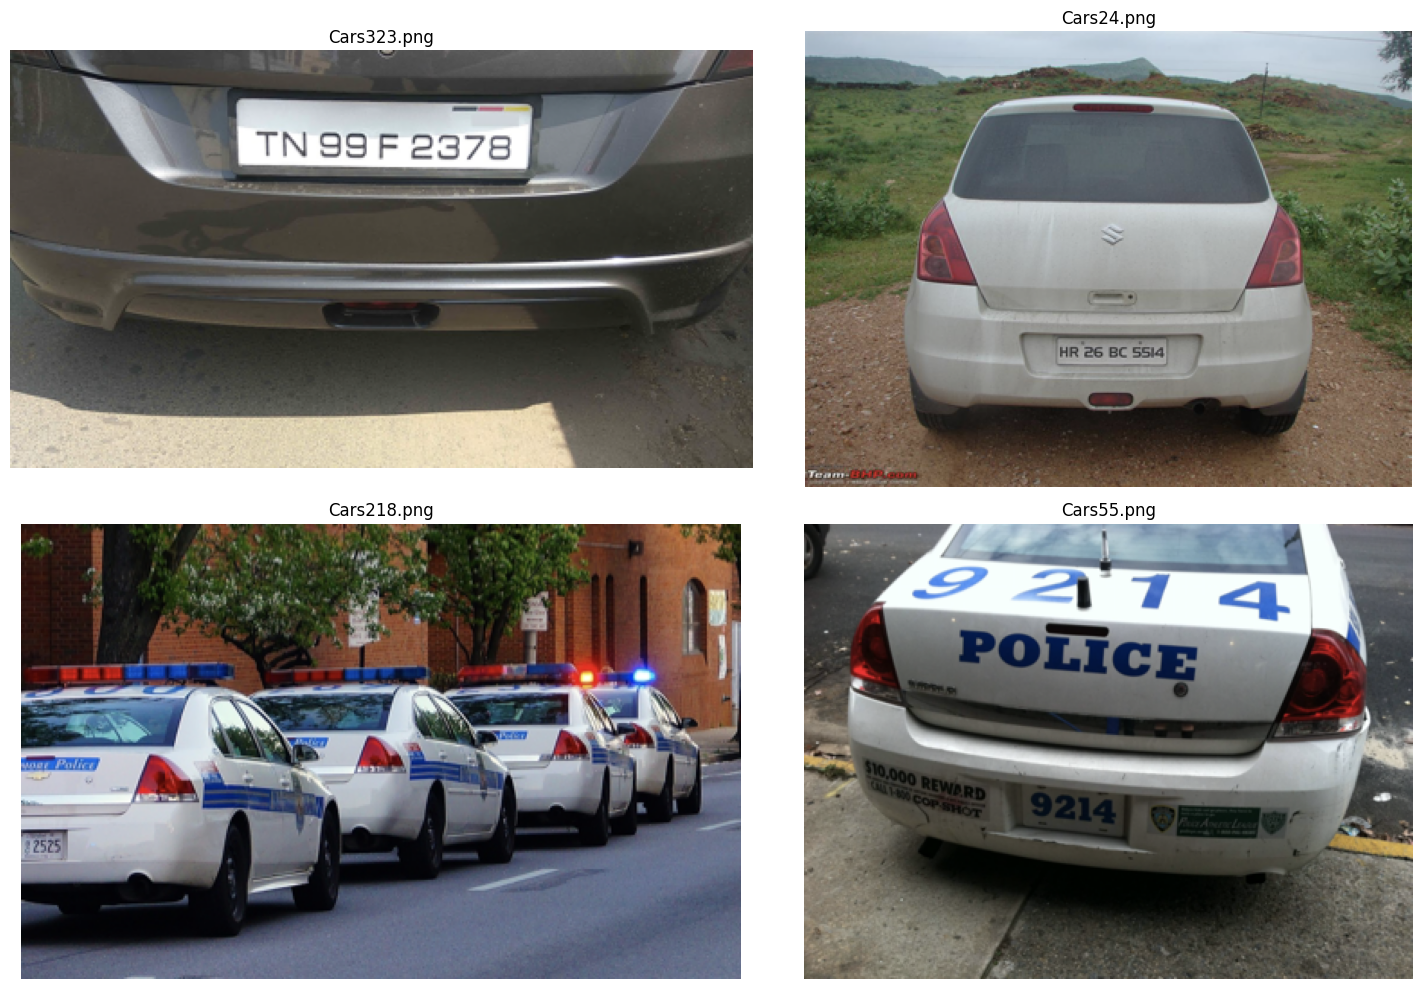

In [7]:
def show_random_images(image_list, n=4):
    sample = random.sample(image_list, min(n, len(image_list)))
    plt.figure(figsize=(15, 10))
    
    for i, img_path in enumerate(sample, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, 2, i)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_random_images(train_images, n=4)

### Yolo training

In [8]:
model = YOLO("yolov8n.pt")

results = model.train(
    data=str(DATA_YAML),
    epochs=75,
    imgsz=512,
    batch=4,
    workers=0,
    project="runs",
    name="plate_detector",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.30  Python-3.11.7 torch-2.11.0+cpu CPU (13th Gen Intel Core i7-13620H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.p

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



      68/75         0G     0.9726     0.5492      1.048          4        512: 100% ━━━━━━━━━━━━ 76/76 2.0s/it 2:291.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.0s/it 9.2s1.3ss
                   all         65         69      0.965      0.809        0.9      0.544

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      69/75         0G     0.9975     0.5425      1.049          3        512: 100% ━━━━━━━━━━━━ 76/76 1.9s/it 2:241.9sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.1s/it 9.6s1.3ss
                   all         65         69      0.917      0.803      0.888      0.542

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      70/75         0G     0.9583     0.5371      1.016          4        512: 100% ━━━━━━━━━━━━ 76/76 2.0s/it 2:301.9ss
                 Class     Images  Insta

### Training results

In [9]:
best_model_path = PROJECT_ROOT / "runs" / "detect" / "runs" / "plate_detector" / "weights" / "best.pt"
print("Best model path:", best_model_path)

if not best_model_path.exists():
    raise FileNotFoundError("best.pt not found. Training may have failed or saved elsewhere.")

best_model = YOLO(str(best_model_path))
print("Best model loaded successfully.")

Best model path: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\runs\detect\runs\plate_detector\weights\best.pt
Best model loaded successfully.


In [10]:
metrics = best_model.val(data=str(DATA_YAML))
metrics

Ultralytics 8.4.30  Python-3.11.7 torch-2.11.0+cpu CPU (13th Gen Intel Core i7-13620H)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 728.8234.5 MB/s, size: 423.6 KB)
val: Scanning C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\labels\val.cache... 65 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 65/65  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.8s/it 8.8s2.9ss
                   all         65         69      0.876      0.826       0.88      0.554
Speed: 0.9ms preprocess, 108.8ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\runs\detect\val2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001C557A30490>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [11]:
pred_results = best_model.predict(
    source=str(IMAGES_VAL),
    save=True,
    conf=0.25,
    project="runs",
    name="plate_detector_predictions",
    exist_ok=True
)


image 1/65 C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\val\Cars100.png: 352x512 1 licence, 158.0ms
image 2/65 C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\val\Cars104.png: 384x512 2 licences, 159.4ms
image 3/65 C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\val\Cars111.png: 288x512 1 licence, 126.8ms
image 4/65 C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\val\Cars112.png: 512x320 2 licences, 134.9ms
image 5/65 C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\val\Cars114.png: 320x512 3 licences, 136.9ms
image 6/65 C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\val\Cars115.png: 416x512 3 licences, 161.7ms
image 7/65 C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\dataset_yolo\images\val

In [12]:
pred_dir = PROJECT_ROOT / "runs" / "plate_detector_predictions"
print("Predictions saved in:", pred_dir)

Predictions saved in: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\runs\plate_detector_predictions


Recent folders:
- runs\detect\val2
- runs\detect
- runs\detect\runs\plate_detector
- runs\detect\runs\plate_detector_predictions
- runs\detect\runs
- runs\detect\val
- runs\detect\runs\plate_detector\weights

Using prediction folder: runs\detect\val2


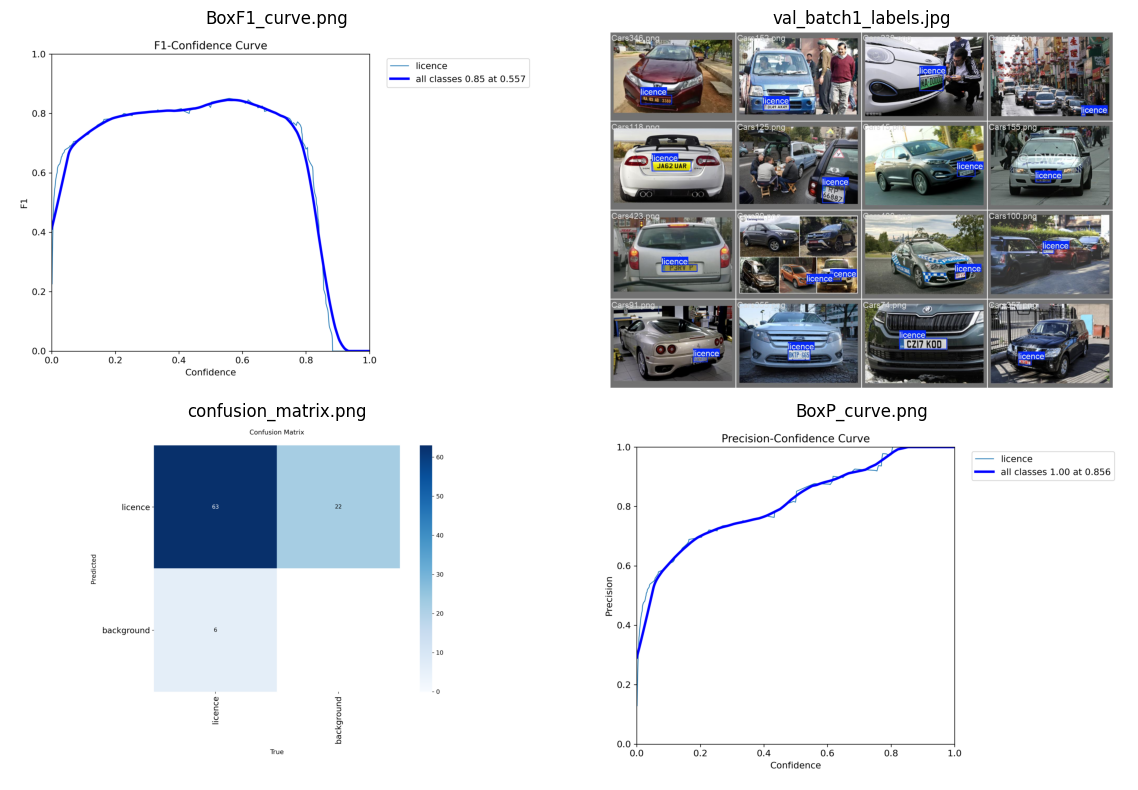

In [13]:
from pathlib import Path
import random
import cv2
import matplotlib.pyplot as plt

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

runs_dir = Path("runs")

if not runs_dir.exists():
    raise FileNotFoundError("runs folder does not exist. You may not have run prediction yet.")

# find latest prediction folder
all_dirs = list(runs_dir.rglob("*"))
all_dirs = [p for p in all_dirs if p.is_dir()]

all_dirs = sorted(all_dirs, key=lambda p: p.stat().st_mtime, reverse=True)

print("Recent folders:")
for p in all_dirs[:10]:
    print("-", p)

# pick first folder that contains images
pred_dir = None
for folder in all_dirs:
    images = list(folder.glob("*.jpg")) + list(folder.glob("*.png"))
    if images:
        pred_dir = folder
        break

if pred_dir is None:
    raise FileNotFoundError("No prediction images found. Did you run prediction?")

print("\nUsing prediction folder:", pred_dir)

predicted_images = [p for p in pred_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]

if not predicted_images:
    print("No predicted images found.")
else:
    sample = random.sample(predicted_images, min(4, len(predicted_images)))
    plt.figure(figsize=(12, 8))

    for i, img_path in enumerate(sample, 1):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 2, i)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [14]:
print("Training complete.")
print("Best model:", best_model_path)
print("Prediction outputs:", pred_dir)

Training complete.
Best model: C:\Users\jjrjg\OneDrive\Desktop\CMPS 261 Project\Plate-Detection-Project\runs\detect\runs\plate_detector\weights\best.pt
Prediction outputs: runs\detect\val2
